<a href="https://colab.research.google.com/github/vamshi3686/Deep-Learning/blob/main/Multilabel_ImageClassification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os

In [ ]:
len(os.listdir('/content/train/paper'))

840

In [ ]:
training_data_path='/content/train'
validation_data_path='/content/valid'
testing_data_path='/content/test'

<function matplotlib.pyplot.show(close=None, block=None)>

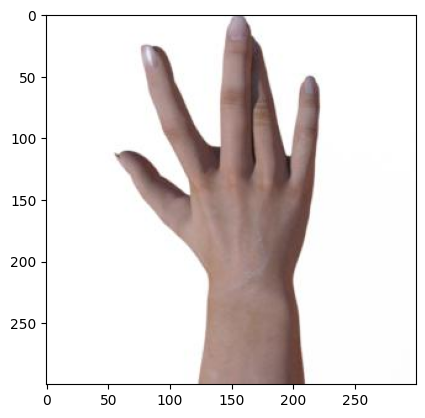

In [ ]:
#paper image
import numpy as np
import matplotlib.pyplot as plt
paper_image=plt.imread(training_data_path+'/paper/paper01-000_png.rf.02152baa06324655efacad9c5bda9f1a.jpg')

plt.imshow(paper_image)
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

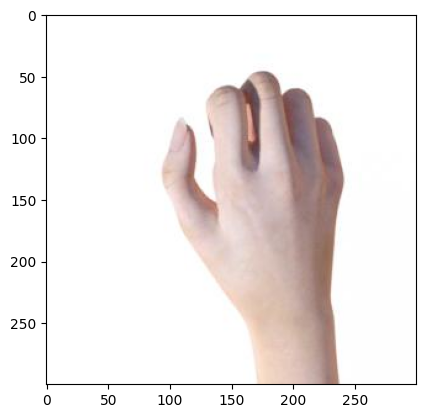

In [ ]:
#rock image
rock_image=plt.imread(training_data_path+"/rock/rock01-000_png.rf.560ebe5b8570f6866c33946448ccf7de.jpg")
plt.imshow(rock_image)
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

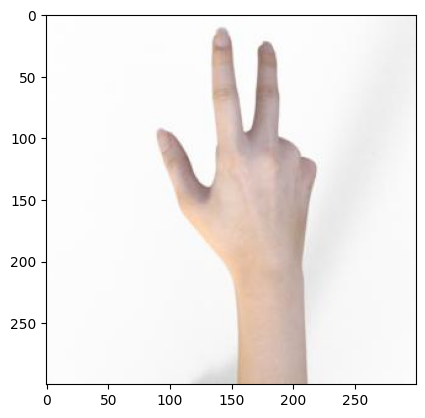

In [ ]:
#scissor image
scissor_image=plt.imread(training_data_path+"/scissors/scissors01-000_png.rf.bc8ea3d7b607fa5306391e214675bc07.jpg")
plt.imshow(scissor_image)
plt.show

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
train_data_preprocesing=ImageDataGenerator(1/255,
                                           rotation_range=0.2,
                                           shear_range=0.2,
                                           horizontal_flip=True)
val_data_preprocesing=ImageDataGenerator(1/255,
                                           rotation_range=0.2,
                                           shear_range=0.2,
                                           horizontal_flip=True)
test_data_preprocesing=ImageDataGenerator(1/255)

In [ ]:
labels=['paper','rock','scissors']

In [ ]:
final_train_data=train_data_preprocesing.flow_from_directory(training_data_path,
                                            target_size=(256, 256),
                                            class_mode='categorical',
                                            classes = labels,
                                            batch_size=20)
final_val_data=val_data_preprocesing.flow_from_directory(validation_data_path,
                                            target_size=(256, 256),
                                            class_mode='categorical',
                                            classes = labels,
                                                         batch_size=20)
final_test_data= test_data_preprocesing.flow_from_directory(testing_data_path,
                                            target_size=(256, 256),
                                            class_mode='categorical',
                                            classes = labels,
                                                            batch_size=20)

Found 2520 images belonging to 3 classes.
Found 372 images belonging to 3 classes.
Found 33 images belonging to 3 classes.


In [ ]:
#Architechture

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, MaxPool2D,Flatten, Activation
from tensorflow.keras.activations import relu, sigmoid, softmax

model=Sequential()

#hiden layer 1
model.add(Conv2D(filters=64, kernel_size=(3,3), padding='Valid', kernel_initializer='he_uniform',activation=relu ))

model.add(MaxPool2D(pool_size=(2,2)))
#hiden layer 2
model.add(Conv2D(filters=16, kernel_size=(3,3), padding='Valid', kernel_initializer='he_uniform',activation=relu ))

model.add(MaxPool2D(pool_size=(2,2)))
#hiden layer 3
model.add(Conv2D(filters=4, kernel_size=(3,3), padding='Valid', kernel_initializer='he_uniform',activation=relu ))

model.add(MaxPool2D(pool_size=(2,2)))

model.add(Flatten())
#give to ann

model.add(Dense(units=64, kernel_initializer='he_uniform',activation=relu))

model.add(Dense(units=16, kernel_initializer='he_uniform',activation=relu))
model.add(Dense(units=4, kernel_initializer='he_uniform',activation=relu))
model.add(Dense(units=3, kernel_initializer='glorot_uniform',activation=softmax))


In [ ]:
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [ ]:
model.fit(final_train_data,validation_data=final_val_data,
          epochs=10)


/usr/local/lib/python3.12/dist-packages/keras/src/legacy/preprocessing/image.py:1261: UserWarning: This ImageDataGenerator specifies `featurewise_center`, but it hasn't been fit on any training data. Fit it first by calling `.fit(numpy_data)`.
  warnings.warn(


Epoch 1/10
126/126 ━━━━━━━━━━━━━━━━━━━━ 48s 350ms/step - accuracy: 0.3647 - loss: 3.5420 - val_accuracy: 0.2957 - val_loss: 1.1023
Epoch 2/10
126/126 ━━━━━━━━━━━━━━━━━━━━ 40s 320ms/step - accuracy: 0.5075 - loss: 0.9749 - val_accuracy: 0.3011 - val_loss: 1.3029
Epoch 3/10
126/126 ━━━━━━━━━━━━━━━━━━━━ 42s 331ms/step - accuracy: 0.6008 - loss: 0.8608 - val_accuracy: 0.3199 - val_loss: 1.4159
Epoch 4/10
126/126 ━━━━━━━━━━━━━━━━━━━━ 41s 322ms/step - accuracy: 0.3468 - loss: 1.0906 - val_accuracy: 0.3333 - val_loss: 1.1020
Epoch 5/10
126/126 ━━━━━━━━━━━━━━━━━━━━ 40s 320ms/step - accuracy: 0.3333 - loss: 1.1010 - val_accuracy: 0.3333 - val_loss: 1.1001
Epoch 6/10
126/126 ━━━━━━━━━━━━━━━━━━━━ 41s 326ms/step - accuracy: 0.3333 - loss: 1.0998 - val_accuracy: 0.3333 - val_loss: 1.0993
Epoch 7/10
126/126 ━━━━━━━━━━━━━━━━━━━━ 40s 318ms/step - accuracy: 0.3333 - loss: 1.0991 - val_accuracy: 0.3333 - val_loss: 1.0989
Epoch 8/10
126/126 ━━━━━━━━━━━━━━━━━━━━ 40s 317ms/step - accuracy: 0.3333 - loss: 1

In [ ]:
import cv2

In [ ]:
def pred_image(image_path):
  image=cv2.imread(image_path,1)
  resized_image=cv2.resize(image, (256,256))
  scaled_pixel_values=resized_image/255
  input_image=np.expand_dims(scaled_pixel_values, axis=0)
  result= model.predict(input_image)
  print(labels[np.argmax(result)])

In [ ]:
pred_image('/content/test/scissors/scissors5_png.rf.ffbe0dd796f6443d73c4bdb80bd21c2f.jpg')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
paper
